In [1]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
import statsmodels.api as sm
import statsmodels.formula.api as smf

from kidneypy.eda import (
    profile_df,
    plot_feature,
)

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_colwidth', 1000)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:2f}'.format)

In [2]:
df = datasets.load_breast_cancer(return_X_y=False, as_frame=True).frame
print(df.shape)
df.head()

(569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.990000,10.380000,122.800000,1001.000000,0.118400,0.277600,0.300100,0.147100,0.241900,0.078710,1.095000,0.905300,8.589000,153.400000,0.006399,0.049040,0.053730,0.015870,0.030030,0.006193,25.380000,17.330000,184.600000,2019.000000,0.162200,0.665600,0.711900,0.265400,0.460100,0.118900,0
1,20.570000,17.770000,132.900000,1326.000000,0.084740,0.078640,0.086900,0.070170,0.181200,0.056670,0.543500,0.733900,3.398000,74.080000,0.005225,0.013080,0.018600,0.013400,0.013890,0.003532,24.990000,23.410000,158.800000,1956.000000,0.123800,0.186600,0.241600,0.186000,0.275000,0.089020,0
2,19.690000,21.250000,130.000000,1203.000000,0.109600,0.159900,0.197400,0.127900,0.206900,0.059990,0.745600,0.786900,4.585000,94.030000,0.006150,0.040060,0.038320,0.020580,0.022500,0.004571,23.570000,25.530000,152.500000,1709.000000,0.144400,0.424500,0.450400,0.243000,0.361300,0.087580,0
3,11.420000,20.380000,77.580000,386.100000,0.142500,0.283900,0.241400,0.105200,0.259700,0.097440,0.495600,1.156000,3.445000,27.230000,0.009110,0.074580,0.056610,0.018670,0.059630,0.009208,14.910000,26.500000,98.870000,567.700000,0.209800,0.866300,0.686900,0.257500,0.663800,0.173000,0
4,20.290000,14.340000,135.100000,1297.000000,0.100300,0.132800,0.198000,0.104300,0.180900,0.058830,0.757200,0.781300,5.438000,94.440000,0.011490,0.024610,0.056880,0.018850,0.017560,0.005115,22.540000,16.670000,152.200000,1575.000000,0.137400,0.205000,0.400000,0.162500,0.236400,0.076780,0


In [3]:
# df['target'] = df['target'].astype(bool)

df['target'] = df['target'].astype(float)
df.loc[0, 'target'] = np.nan

In [4]:
profile_df(df)

,type,n_unique,p_unique,n_na,p_na,any_inf,mode,n_mode,p_mode,mean,std,min,25%,50%,75%,max,out_iqr,out_std
mean radius,float64,456,0.801406,0,0.000000,False,NaN,NaN,NaN,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000,True,True
mean texture,float64,479,0.841828,0,0.000000,False,NaN,NaN,NaN,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000,True,True
mean perimeter,float64,522,0.917399,0,0.000000,False,NaN,NaN,NaN,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000,True,True
mean area,float64,539,0.947276,0,0.000000,False,NaN,NaN,NaN,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000,True,True
mean smoothness,float64,474,0.833040,0,0.000000,False,NaN,NaN,NaN,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400,True,True
mean compactness,float64,537,0.943761,0,0.000000,False,NaN,NaN,NaN,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400,True,True
mean concavity,float64,537,0.943761,0,0.000000,False,NaN,NaN,NaN,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800,True,True
mean concave points,float64,542,0.952548,0,0.000000,False,NaN,NaN,NaN,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200,True,True
mean symmetry,float64,432,0.759227,0,0.000000,False,NaN,NaN,NaN,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000,True,True
mean fractal dimension,float64,499,0.876977,0,0.000000,False,NaN,NaN,NaN,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440,True,True


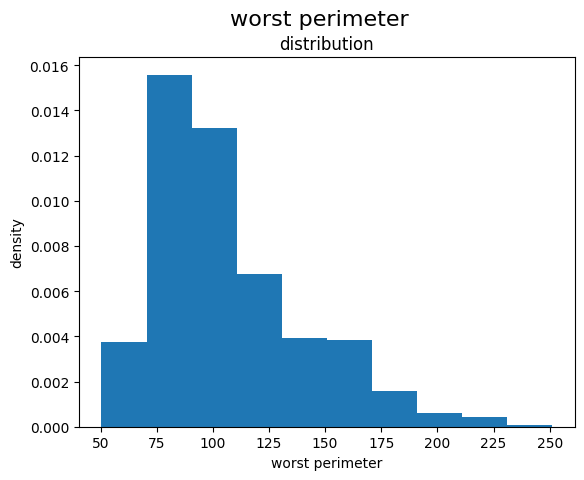

In [5]:
fig, ax = plot_feature(df, feature_col='worst perimeter')

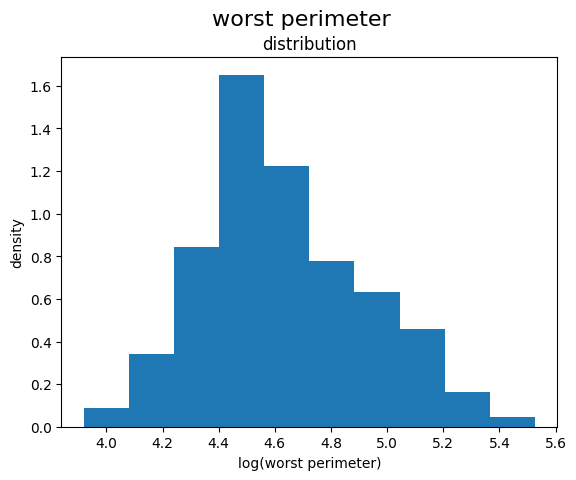

In [6]:
fig, ax = plot_feature(df, feature_col='worst perimeter', log=True)

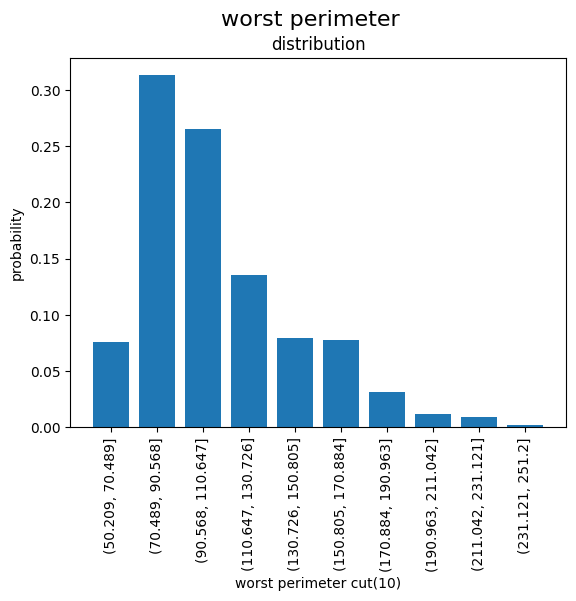

In [7]:
fig, ax = plot_feature(df, feature_col='worst perimeter', discretize=True)

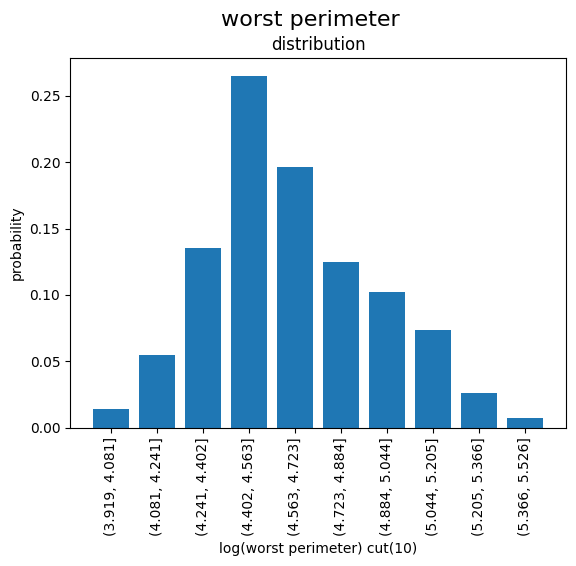

In [8]:
fig, ax = plot_feature(df, feature_col='worst perimeter', log=True, discretize=True)

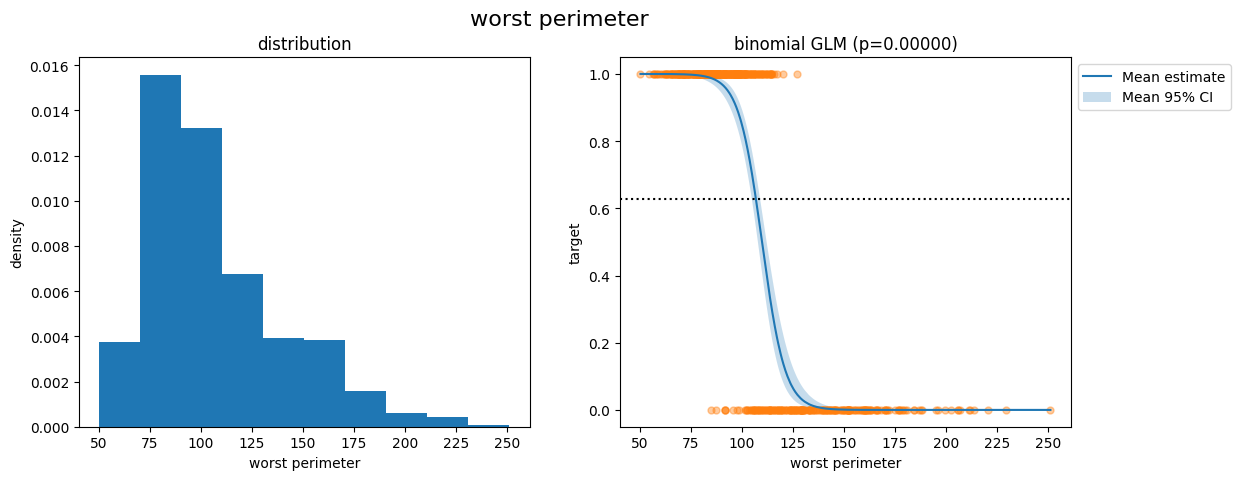

In [9]:
fig, ax = plot_feature(df, feature_col='worst perimeter', target_col='target', family='binomial')

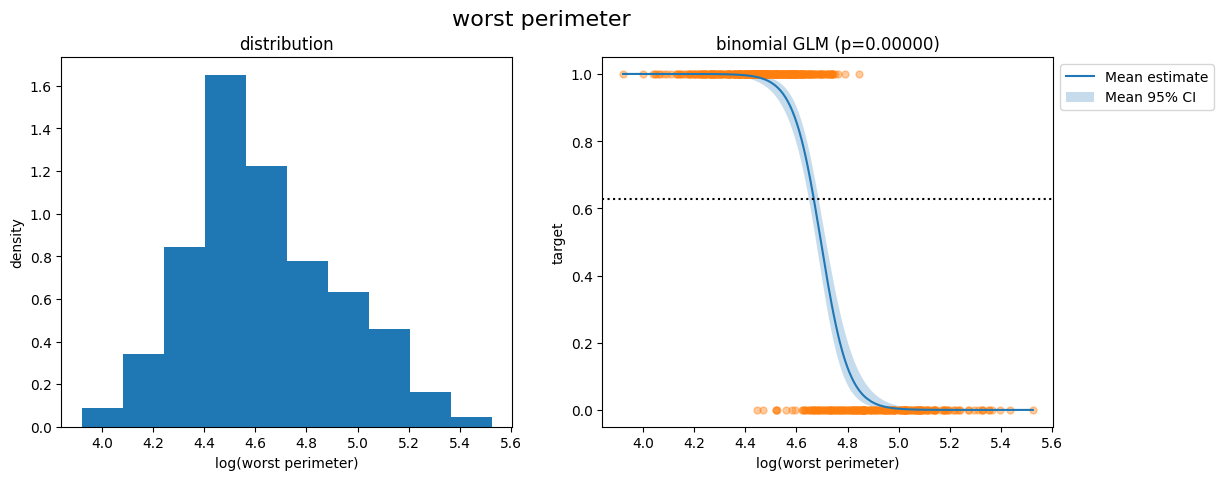

In [10]:
fig, ax = plot_feature(df, feature_col='worst perimeter', target_col='target', family='binomial', log=True)

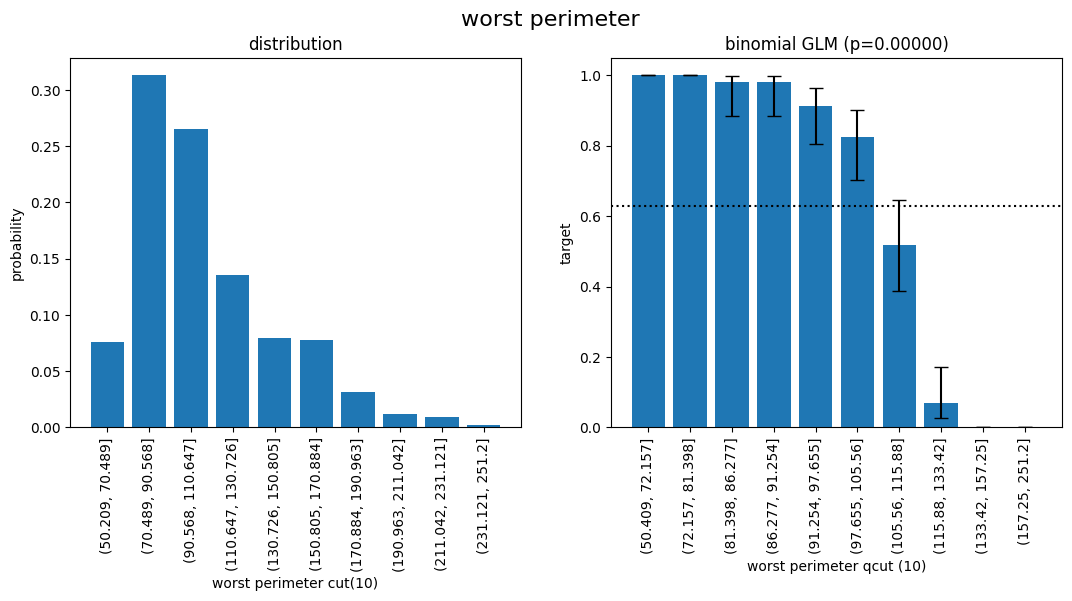

In [11]:
fig, ax = plot_feature(df, feature_col='worst perimeter', target_col='target', family='binomial', discretize=True)

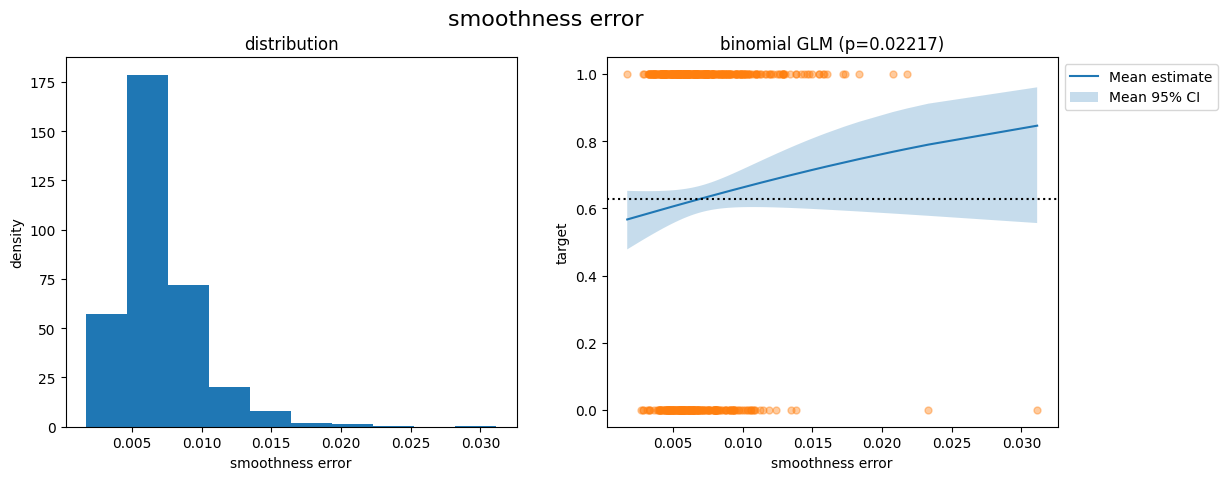

In [13]:
fig, ax = plot_feature(df, feature_col='smoothness error', target_col='target', family='binomial')

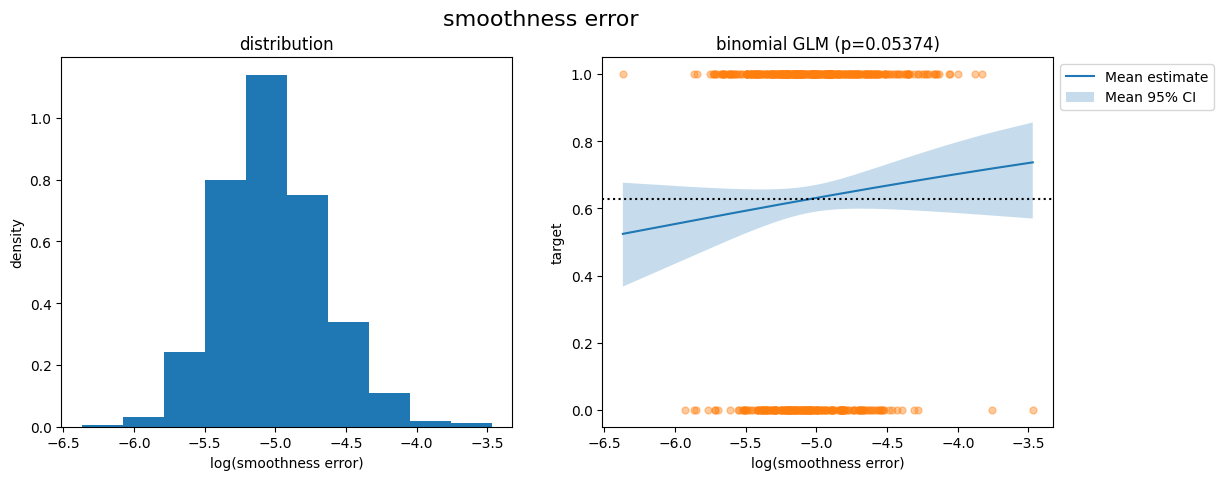

In [14]:
fig, ax = plot_feature(df, feature_col='smoothness error', target_col='target', family='binomial', log=True)

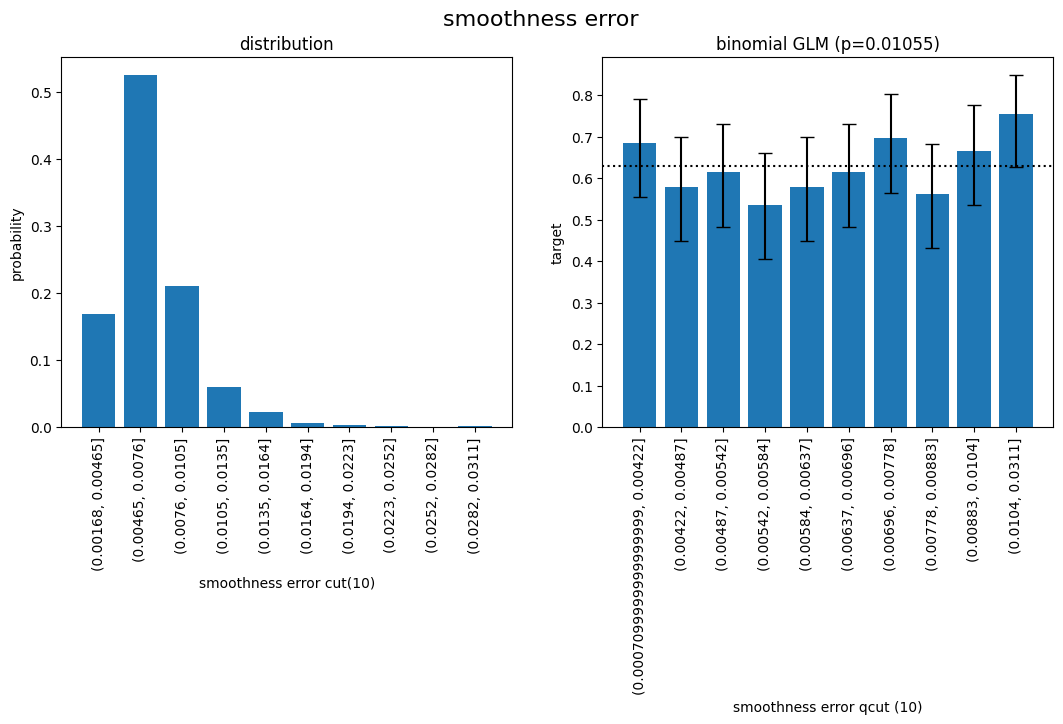

In [15]:
fig, ax = plot_feature(df, feature_col='smoothness error', target_col='target', family='binomial', discretize=True)

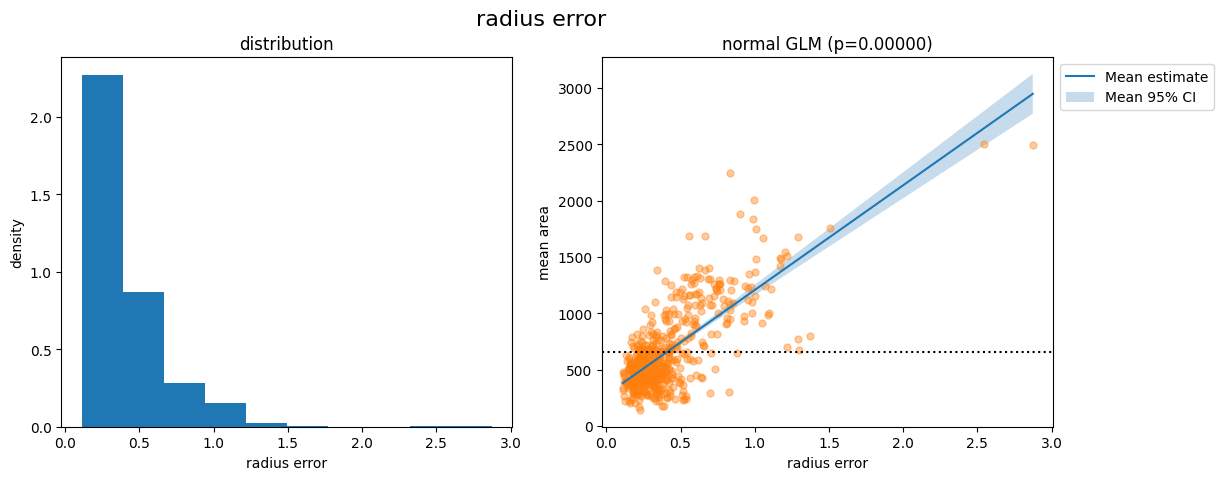

In [16]:
fig, ax = plot_feature(df, feature_col='radius error', target_col='mean area', family='normal')

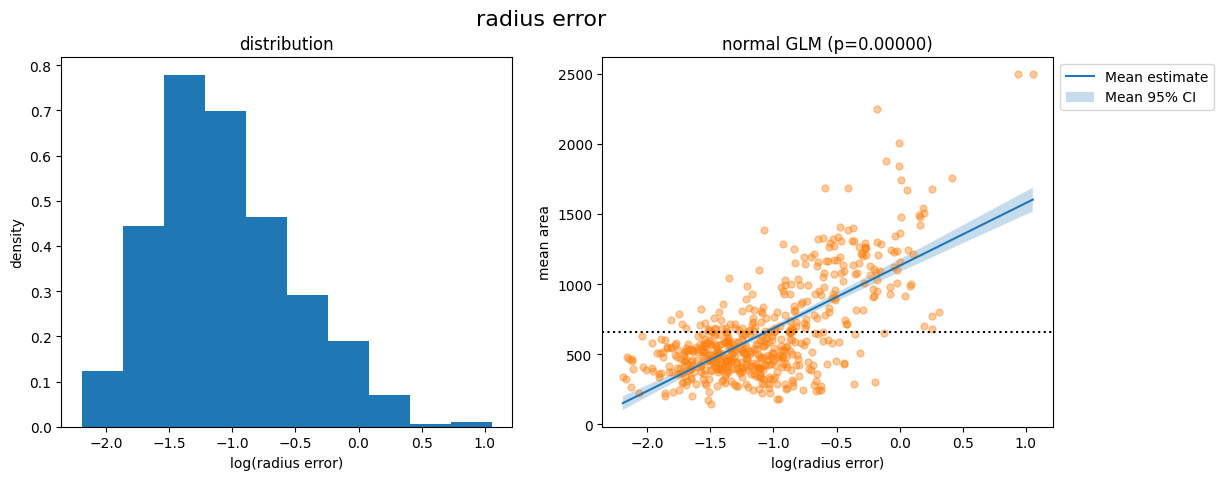

In [18]:
fig, ax = plot_feature(df, feature_col='radius error', target_col='mean area', family='normal', log=True)

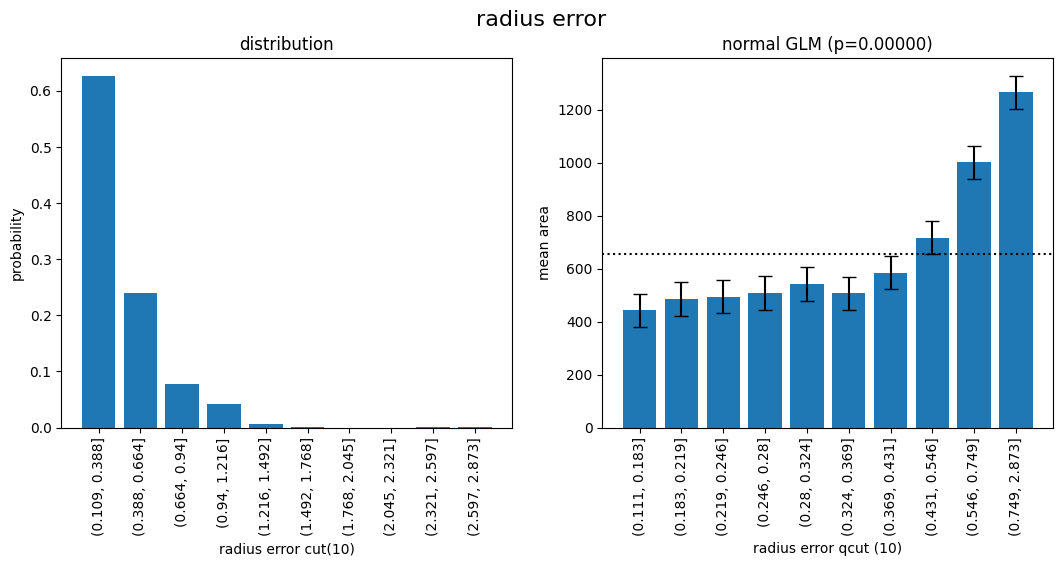

In [17]:
fig, ax = plot_feature(df, feature_col='radius error', target_col='mean area', family='normal', discretize=True)